In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC as ClassicalSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
import os
warnings.filterwarnings('ignore')

# Quantum ML libraries
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import NesterovMomentumOptimizer, AdamOptimizer

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")


PennyLane version: 0.44.1
NumPy version: 2.4.1


In [14]:
# Load data (works on both Kaggle and local)
import os

if os.path.exists('/kaggle/input/titanic/train.csv'):
    # Kaggle environment
    DATA_PATH = '/kaggle/input/titanic'
else:
    # Local environment
    DATA_PATH = './data'

train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
train_df.head()

Training set: (891, 12)
Test set: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
def preprocess_data(df, is_train=True):
    """
    Preprocess Titanic data for quantum classification.
    
    For quantum circuits, we need to:
    1. Handle missing values
    2. Encode categorical variables
    3. Select features (limited by qubit count)
    4. Normalize features to [0, pi] for angle encoding
    """
    df = df.copy()
    
    # Fill missing values
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Feature engineering
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 
                                        'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # Encode categorical
    df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
    df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])
    df['Title'] = LabelEncoder().fit_transform(df['Title'])
    
    # Select features for quantum model (limited qubits = limited features)
    # We select 4 features for a 4-qubit circuit
    features = ['Pclass', 'Sex', 'Age', 'Fare']
    
    X = df[features].values
    y = df['Survived'].values if is_train else None
    
    return X, y, df

X_full, y_full, train_processed = preprocess_data(train_df, is_train=True)
print(f"Features shape: {X_full.shape}")
print(f"Feature columns: Pclass, Sex, Age, Fare")

Features shape: (891, 4)
Feature columns: Pclass, Sex, Age, Fare


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

def normalize_to_angle(X):
    X_bounded = np.arctan(X) / (np.pi/2)
    X_angle = (X_bounded + 1) * (np.pi / 2) / 2
    return X_angle

X_quantum = normalize_to_angle(X_scaled)

X_train, X_val, y_train, y_val = train_test_split(X_quantum, y_full, test_size=0.2, random_state=42, stratify=y_full)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Feature range: [{X_quantum.min():.3f}, {X_quantum.max():.3f}]")

Training samples: 712
Validation samples: 179
Feature range: [0.211, 1.519]


In [17]:
X_train_classical, X_val_classical, _, _ = train_test_split(X_scaled, y_full, test_size=0.2, random_state=42, stratify=y_full)

classical_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVM (RBF)' : SVC(kernel='rbf', probability=True),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

classical_results = {}
print("Classical Model Performance (4 features only)")
print("=" * 50)

for name, model in classical_models.items():
    model.fit(X_train_classical, y_train)
    y_pred = model.predict(X_val_classical)
    y_prob = model.predict_proba(X_val_classical)[:, 1]
    
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    classical_results[name] = {'accuracy' : acc, 'auc' : auc}

    print(f"{name:25s} | Accuracy: {acc:.4f} | AUC: {auc:.4f}")

Classical Model Performance (4 features only)
Logistic Regression       | Accuracy: 0.7877 | AUC: 0.8361
SVM (RBF)                 | Accuracy: 0.8045 | AUC: 0.8257
Random Forest             | Accuracy: 0.8324 | AUC: 0.8431
Gradient Boosting         | Accuracy: 0.8045 | AUC: 0.8117


Quantum Circuit Structure:


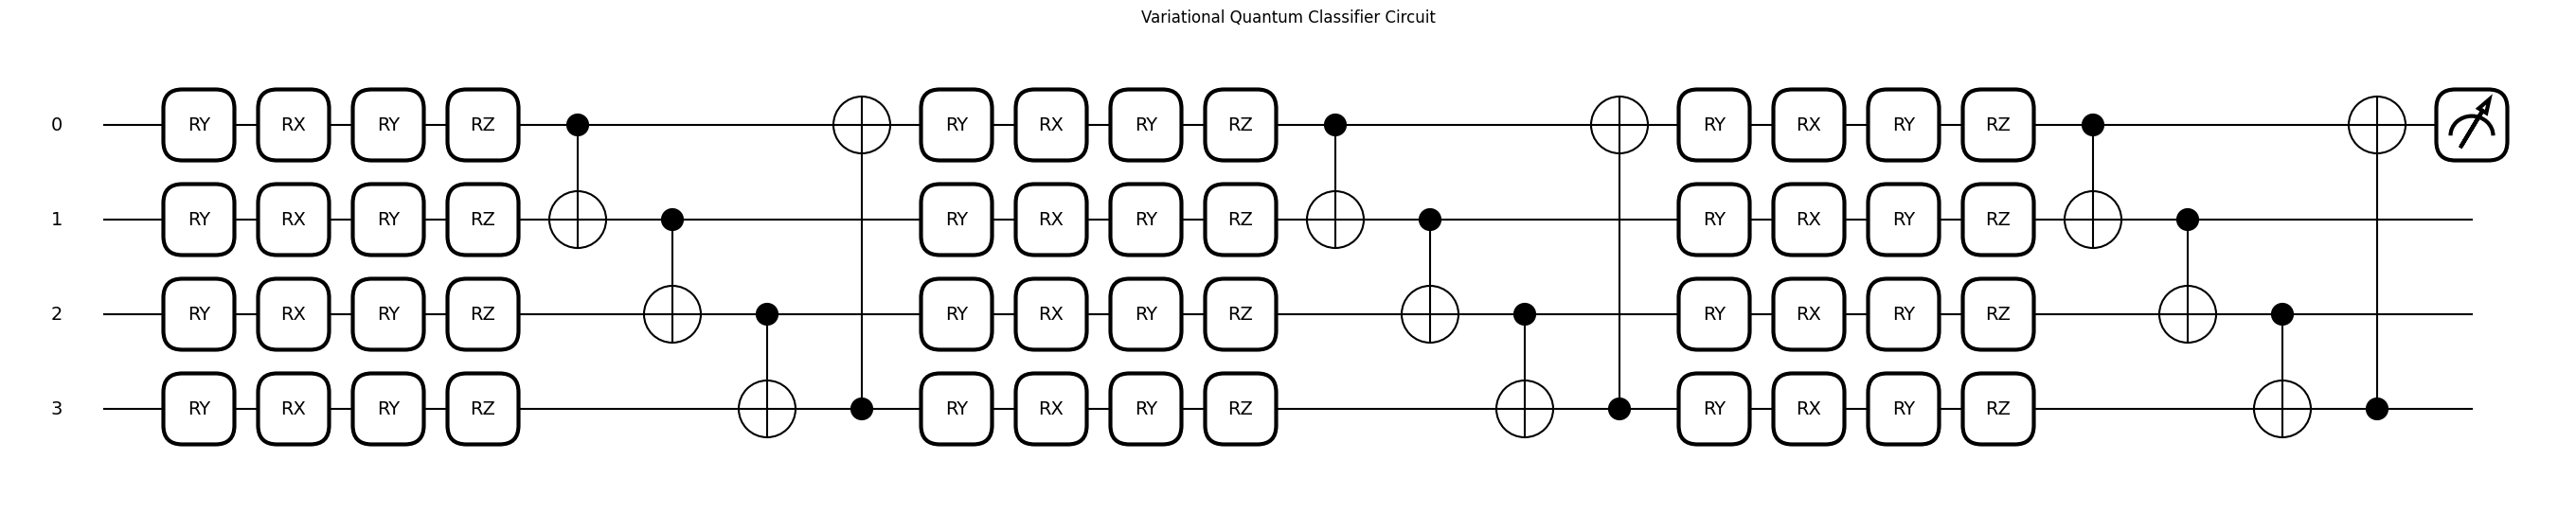

In [18]:
n_qubits = 4
n_layers = 3

dev = qml.device('default.qubit', wires=n_qubits)

def angle_encoding(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    
def variational_layer(weights, layer_idx):
    for i in range(n_qubits):
        qml.RX(weights[layer_idx, i, 0], wires=i)
        qml.RY(weights[layer_idx, i, 1], wires=i)
        qml.RZ(weights[layer_idx, i, 2], wires=i)
    
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

@qml.qnode(dev)
def quantum_circuit(weights, x):
    angle_encoding(x)
    for layer in range(n_layers):
        variational_layer(weights, layer)
        if layer < n_layers - 1:
            angle_encoding(x)
    
    return qml.expval(qml.PauliZ(0))

print("Quantum Circuit Structure:")
print("=" * 50)

weight_shape = (n_layers, n_qubits, 3)
sample_weights = pnp.random.uniform(0, 2*np.pi, weight_shape, requires_grad=True)
sample_x = X_train[0]

fig, ax = qml.draw_mpl(quantum_circuit)(sample_weights, sample_x)
plt.title("Variational Quantum Classifier Circuit")
plt.tight_layout()
plt.show()

In [19]:
def quantum_classifier(weights, bias, x):
    return quantum_circuit(weights, x) + bias

def predict_batch(weights, bias, X):
    predictions = [quantum_classifier(weights, bias, x) for x in X]
    return pnp.array(predictions)

def square_loss(labels, predictions):
    labels_converted = 2 * labels - 1
    return pnp.mean((labels_converted - predictions) ** 2)

def cost(weights, bias, X, y):
    predictions = predict_batch(weights, bias, X)
    return square_loss(y, predictions)

def accuracy_quantum(weights, bias, X, y):
    predictions = predict_batch(weights, bias, X)
    y_pred = (predictions > 0).astype(int)
    return pnp.mean(y_pred == y)

In [20]:
n_epochs = 50
batch_size = 32
learning_rate = 0.1

# Initialize parameters
pnp.random.seed(42)
weights = pnp.random.uniform(0, 2*np.pi, (n_layers, n_qubits, 3), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

# Use Nesterov Momentum Optimizer (recommended in PennyLane tutorials)
opt = NesterovMomentumOptimizer(stepsize=learning_rate)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': []
}

# Subsample for faster training (quantum simulation is slow)
n_train_subset = min(200, len(X_train))
train_indices = np.random.choice(len(X_train), n_train_subset, replace=False)
X_train_subset = X_train[train_indices]
y_train_subset = y_train[train_indices]

n_val_subset = min(50, len(X_val))
val_indices = np.random.choice(len(X_val), n_val_subset, replace=False)
X_val_subset = X_val[val_indices]
y_val_subset = y_val[val_indices]

print(f"Training on {n_train_subset} samples, validating on {n_val_subset} samples")
print(f"Circuit: {n_qubits} qubits, {n_layers} layers")
print("=" * 60)

# Training loop
for epoch in range(n_epochs):
    # Mini-batch training
    batch_indices = np.random.choice(n_train_subset, batch_size, replace=False)
    X_batch = X_train_subset[batch_indices]
    y_batch = y_train_subset[batch_indices]
    
    # Gradient descent step
    (weights, bias), _cost = opt.step_and_cost(
        lambda w, b: cost(w, b, X_batch, y_batch),
        weights, bias
    )
    
    # Calculate metrics 
    train_loss = cost(weights, bias, X_train_subset, y_train_subset)
    train_acc = accuracy_quantum(weights, bias, X_train_subset, y_train_subset)
    val_acc = accuracy_quantum(weights, bias, X_val_subset, y_val_subset)
        
    history['train_loss'].append(float(train_loss))
    history['train_acc'].append(float(train_acc))
    history['val_acc'].append(float(val_acc))
        
    print(f"Epoch {epoch+1:3d} | Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Training on 200 samples, validating on 50 samples
Circuit: 4 qubits, 3 layers
Epoch   1 | Loss: 0.7324 | Train Acc: 0.7700 | Val Acc: 0.7000
Epoch   2 | Loss: 0.7038 | Train Acc: 0.7650 | Val Acc: 0.7400
Epoch   3 | Loss: 0.6857 | Train Acc: 0.7400 | Val Acc: 0.6800
Epoch   4 | Loss: 0.6729 | Train Acc: 0.7500 | Val Acc: 0.6800
Epoch   5 | Loss: 0.6615 | Train Acc: 0.7650 | Val Acc: 0.7400
Epoch   6 | Loss: 0.6582 | Train Acc: 0.7950 | Val Acc: 0.8000
Epoch   7 | Loss: 0.6558 | Train Acc: 0.7850 | Val Acc: 0.8200
Epoch   8 | Loss: 0.6347 | Train Acc: 0.7800 | Val Acc: 0.7200
Epoch   9 | Loss: 0.6417 | Train Acc: 0.7500 | Val Acc: 0.6600
Epoch  10 | Loss: 0.6379 | Train Acc: 0.7600 | Val Acc: 0.6600
Epoch  11 | Loss: 0.6287 | Train Acc: 0.7900 | Val Acc: 0.6800
Epoch  12 | Loss: 0.6198 | Train Acc: 0.8050 | Val Acc: 0.8000
Epoch  13 | Loss: 0.6175 | Train Acc: 0.7850 | Val Acc: 0.8200
Epoch  14 | Loss: 0.6166 | Train Acc: 0.7850 | Val Acc: 0.8200
Epoch  15 | Loss: 0.6387 | Train Acc: 0.

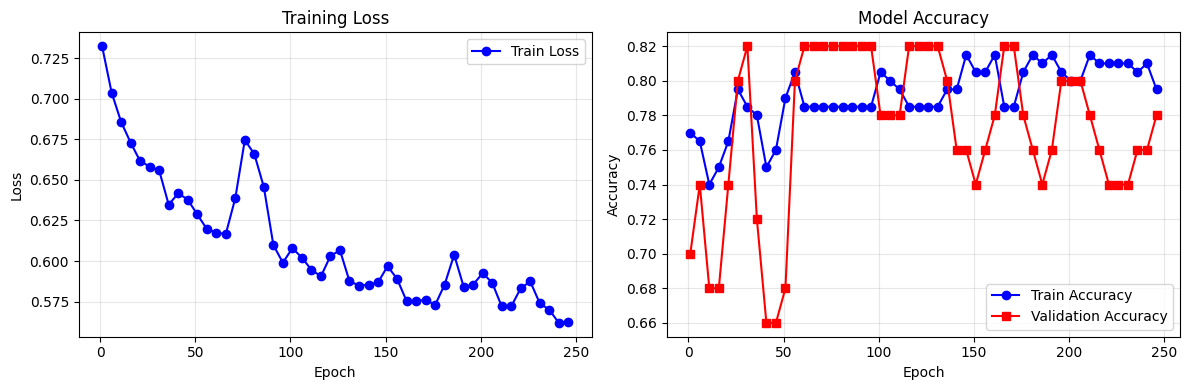

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_recorded = list(range(1, len(history['train_loss'])*5, 5))
if len(epochs_recorded) > len(history['train_loss']):
    epochs_recorded = epochs_recorded[:len(history['train_loss'])]

# Loss
axes[0].plot(epochs_recorded, history['train_loss'], 'b-', label='Train Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_recorded, history['train_acc'], 'b-', label='Train Accuracy', marker='o')
axes[1].plot(epochs_recorded, history['val_acc'], 'r-', label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
quantum_val_acc = accuracy_quantum(weights, bias, X_val, y_val)

# Get predictions for confusion matrix
quantum_predictions = predict_batch(weights, bias, X_val)
quantum_y_pred = (quantum_predictions > 0).astype(int)

print("="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)
print(f"\n{'Model':<30} | {'Accuracy':>10} | {'AUC':>10}")
print("-"*60)

# Classical results
for name, results in classical_results.items():
    print(f"{name:<30} | {results['accuracy']:>10.4f} | {results['auc']:>10.4f}")

# Quantum result
print("-"*60)
print(f"{'Variational Quantum Classifier':<30} | {float(quantum_val_acc):>10.4f} | {'N/A':>10}")
print("="*60)

FINAL RESULTS COMPARISON

Model                          |   Accuracy |        AUC
------------------------------------------------------------
Logistic Regression            |     0.7877 |     0.8361
SVM (RBF)                      |     0.8045 |     0.8257
Random Forest                  |     0.8324 |     0.8431
Gradient Boosting              |     0.8045 |     0.8117
------------------------------------------------------------
Variational Quantum Classifier |     0.7542 |        N/A


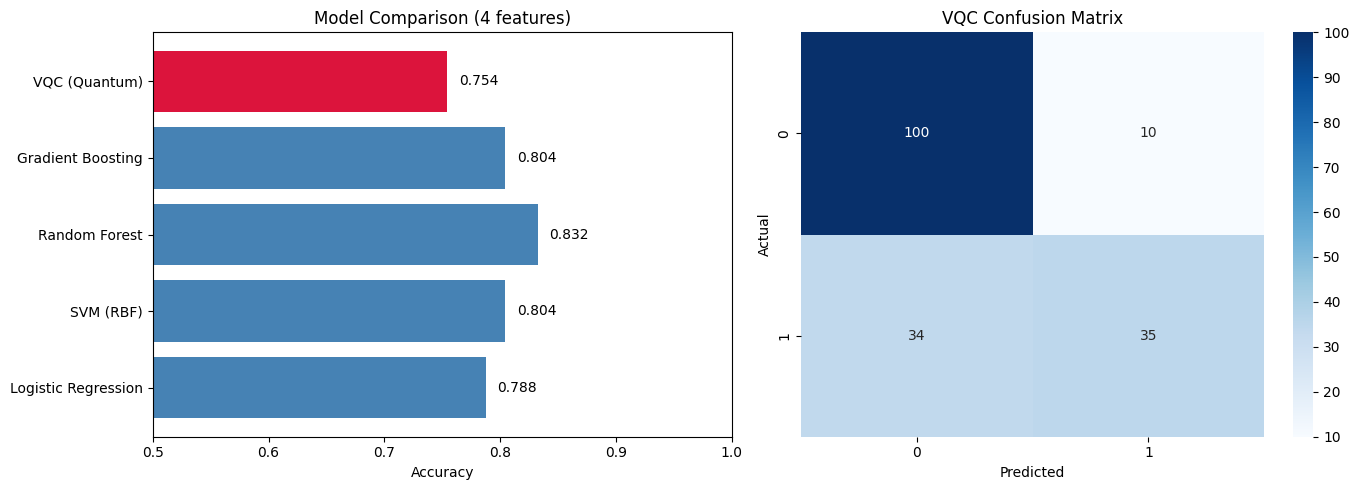

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
models = list(classical_results.keys()) + ['VQC (Quantum)']
accuracies = [classical_results[m]['accuracy'] for m in classical_results.keys()] + [float(quantum_val_acc)]
colors = ['steelblue'] * len(classical_results) + ['crimson']

axes[0].barh(models, accuracies, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Comparison (4 features)')
axes[0].set_xlim(0.5, 1.0)
for i, (model, acc) in enumerate(zip(models, accuracies)):
    axes[0].text(acc + 0.01, i, f'{acc:.3f}', va='center')

# Confusion matrix for quantum model
cm = confusion_matrix(y_val, quantum_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('VQC Confusion Matrix')

plt.tight_layout()
plt.show()

Quantum Kernel circuit:


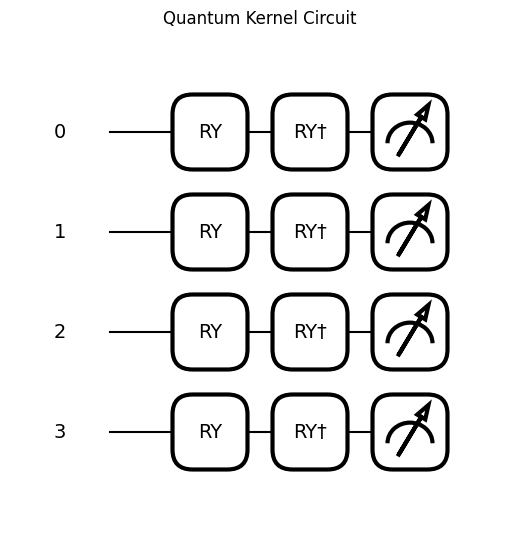

In [24]:
@qml.qnode(dev)
def quantum_kernel_circuit(x1, x2):
    """
    Quantum kernel: compute overlap between two quantum-encoded states.
    K(x1, x2) = |<phi(x1)|phi(x2)>|^2
    """
    # Encode first data point
    angle_encoding(x1)
    
    # Apply adjoint (inverse) of second data point encoding
    qml.adjoint(angle_encoding)(x2)
    
    # Measure probability of returning to |0...0>
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    """Compute quantum kernel value between two samples."""
    probs = quantum_kernel_circuit(x1, x2)
    return probs[0]  # Probability of measuring |0000>

def compute_kernel_matrix(X1, X2=None, verbose=True):
    """Compute the kernel matrix for datasets X1 and X2."""
    if X2 is None:
        X2 = X1
    
    n1, n2 = len(X1), len(X2)
    K = np.zeros((n1, n2))
    
    total = n1 * n2
    count = 0
    
    for i in range(n1):
        for j in range(n2):
            K[i, j] = quantum_kernel(X1[i], X2[j])
            count += 1
            
        if verbose and (i + 1) % 10 == 0:
            print(f"  Progress: {count}/{total} ({100*count/total:.1f}%)")
    
    return K

print("Quantum Kernel circuit:")
fig, ax = qml.draw_mpl(quantum_kernel_circuit)(X_train[0], X_train[1])
plt.title("Quantum Kernel Circuit")
plt.tight_layout()
plt.show()

In [25]:
n_kernel_samples = 80  # Small subset for demonstration
kernel_train_idx = np.random.choice(len(X_train), n_kernel_samples, replace=False)
kernel_val_idx = np.random.choice(len(X_val), 30, replace=False)

X_kernel_train = X_train[kernel_train_idx]
y_kernel_train = y_train[kernel_train_idx]
X_kernel_val = X_val[kernel_val_idx]
y_kernel_val = y_val[kernel_val_idx]

print(f"Computing kernel matrix ({n_kernel_samples}x{n_kernel_samples})...")
K_train = compute_kernel_matrix(X_kernel_train)

print(f"\nComputing test kernel matrix...")
K_val = compute_kernel_matrix(X_kernel_val, X_kernel_train, verbose=False)

# Train SVM with precomputed quantum kernel
qsvm = ClassicalSVC(kernel='precomputed')
qsvm.fit(K_train, y_kernel_train)

# Predict
qsvm_pred = qsvm.predict(K_val)
qsvm_acc = accuracy_score(y_kernel_val, qsvm_pred)

print(f"\nQuantum Kernel SVM Accuracy: {qsvm_acc:.4f}")

Computing kernel matrix (80x80)...
  Progress: 800/6400 (12.5%)
  Progress: 1600/6400 (25.0%)
  Progress: 2400/6400 (37.5%)
  Progress: 3200/6400 (50.0%)
  Progress: 4000/6400 (62.5%)
  Progress: 4800/6400 (75.0%)
  Progress: 5600/6400 (87.5%)
  Progress: 6400/6400 (100.0%)

Computing test kernel matrix...

Quantum Kernel SVM Accuracy: 0.8000
